In [8]:
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.lines import Line2D
import random
import itertools

sys.path.append('../')

from src.piece_functions import helix,cast_and_surge,persistent_random_walk,straight_line,generate_random_trajectory
from src.io import save_dataframe

In [32]:
def canonicalize_trajectory_1(coords, *, return_rotation=False, tol=1e-12):
    """
    Rotate `coords` (K×3) into a unique canonical frame.
    Any rigid-body rotation + translation of the same trajectory
    maps to the *identical* output.

    Algorithm
    ---------
    1.  centre at the centroid
    2.  PCA → eigenvectors V (columns)
    3.  for each axis j:                       # sign disambiguation
        m3 = Σ (x_j')³   (third central moment)
        if |m3| < tol use   Σ x_j'² x_{j+1}'
        flip V[:,j] if m3 < 0
    4.  make the basis right-handed (det = +1)
    5.  rotated = centred @ V

    Returns
    -------
    canon : (K,3)  canonical coordinates (centroid at the origin)
    R      : (3,3) rotation matrix  (only if `return_rotation=True`)
    """

    X   = np.asarray(coords, dtype=float)
    C   = X - X.mean(axis=0)               # 1
    _,  _, Vt = np.linalg.svd(C, full_matrices=False)
    V   = Vt.T                             # 2

    Y   = C @ V                            # projections for moments
    for j in range(3):                     # 3
        m3 = (Y[:, j] ** 3).sum()
        if abs(m3) < tol:                  # nearly symmetric
            k = (j + 1) % 3
            m3 = (Y[:, j]**2 * Y[:, k]).sum()
        if m3 < 0:
            V[:, j] *= -1
            Y[:, j] *= -1

    if np.linalg.det(V) < 0:               # 4
        V[:, 2] *= -1
        Y[:, 2] *= -1

    canon = Y                               # 5
    print(canon.shape)
    ## Step 6: chiral disambiguation via lexicographic minimization
    mirrors = np.array([
        [ 1,  1,  1],
        [-1,  1,  1],
        [ 1, -1,  1],
        [ 1,  1, -1],
        [-1, -1,  1],
        [-1,  1, -1],
        [ 1, -1, -1],
        [-1, -1, -1]
    ])  # shape (8, 3)
    print(mirrors.shape)
    mirrored = np.einsum('ij,kj->kij', canon, mirrors)  #µ shape (8, K, 3)
    print(mirrored.shape)

    flat = mirrored.reshape(8, -1)  # shape (8, 3K)
    best_index = np.lexsort(flat.T)[0]
    canon = mirrored[best_index]

    return (canon, V) if return_rotation else canon

def canonicalize_trajectory(coords, *, return_rotation=False, tol=1e-12):
    """
    Rotate `coords` (K×D) into a unique canonical frame.
    Works for 2D (D=2) and 3D (D=3).
    
    Any rigid-body rotation + translation of the same trajectory
    maps to the *identical* output.
    """
    X = np.asarray(coords, dtype=float)
    K, D = X.shape                     # Detect dimensionality (2 or 3)
    
    # 1. Centre at centroid
    C = X - X.mean(axis=0)
    
    # 2. PCA -> eigenvectors V
    # Vt is (D, D), V is (D, D)
    _, _, Vt = np.linalg.svd(C, full_matrices=False)
    V = Vt.T

    Y = C @ V
    
    # 3. Sign disambiguation (loop over D dimensions)
    for j in range(D):
        m3 = (Y[:, j] ** 3).sum()
        if abs(m3) < tol:
            k = (j + 1) % D            # Wrap around (0->1, 1->2 or 1->0)
            m3 = (Y[:, j]**2 * Y[:, k]).sum()
        if m3 < 0:
            V[:, j] *= -1
            Y[:, j] *= -1

    # 4. Make basis right-handed (det = +1)
    if np.linalg.det(V) < 0:
        V[:, -1] *= -1                 # Flip last axis (generic for 2D/3D)
        Y[:, -1] *= -1

    canon = Y

    # Step 6: Chiral disambiguation via lexicographic minimization
    # Generate mirrors dynamically for D dimensions (4 for 2D, 8 for 3D)
    mirrors = np.array(list(itertools.product([1, -1], repeat=D)))  # shape (2^D, D)

    # (2^D, D) x (K, D) -> (2^D, K, D) via broadcasting/einsum
    # Einstein sum: 'ij,kj->kij' (mirrors[i, j] * canon[k, j])
    mirrored = np.einsum('ij,kj->kij', canon,mirrors)

    flat = mirrored.reshape(len(mirrors), -1)  # shape (2^D, K*D)
    best_index = np.lexsort(flat.T)[0]
    canon = mirrored[best_index]

    return (canon, V) if return_rotation else canon

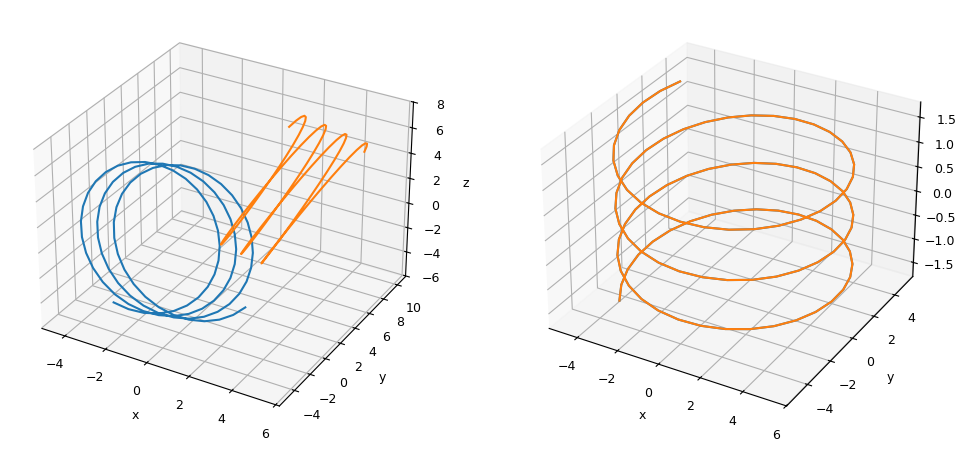

In [33]:
x1,y1,z1 =  helix(start = np.array([0.,0.,0.]), n_steps=100, radius=5, pitch=1.0, clockwise=True, step=1.0)
x2,y2,z2 =  helix(start = np.array([1.,5.,3.]), n_steps=100, radius=5, pitch=-1.0, clockwise=False, step=1.0)
fig,ax = plt.subplots(ncols= 2,subplot_kw={"projection":'3d'},figsize=(12,6))
ax[0].plot(x1,y1,z1)
ax[0].plot(x2,y2,z2)

xyz1 = canonicalize_trajectory(np.array([x1,y1,z1]).T)
#xyz2 = canonicalize_trajectory_1(np.array([x1,y1,z1]).T)
xyz2 = canonicalize_trajectory(np.array([x2,y2,z2]).T)

ax[1].plot(xyz1[:,0],xyz1[:,1],xyz1[:,2])
ax[1].plot(xyz2[:,0],xyz2[:,1],xyz2[:,2])
for i in range(2):
    ax[i].set_xlabel('x')
    ax[i].set_ylabel('y')
    ax[i].set_zlabel('z')
#fig.savefig('helix_disambiguation.pdf',bbox_inches='tight')